# PortugeseBank

## 1. LOAD AND DATA CLEANING

### 1.1 IMPORTS AND LOAD DATA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import scipy.stats as ss
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE               # create artificial 'yes' to have 50/50 data 'yes' and 'no'
from imblearn.pipeline import Pipeline as imbpipeline
#show the graphs after the linecode
%matplotlib inline                                     

#MACHINE LEARNING
import xgboost as xgb
from xgboost import XGBClassifier
print(f"Scipy: {scipy.__version__}")                   #I need to know Scipy version to install in my M5Pro for compatibility reasons
print(f"XGBoost: {xgb.__version__}")
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import sklearn.metrics as me
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import classification_report 
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight

Scipy: 1.16.0
XGBoost: 3.2.0


In [2]:
# load the data and separate the columns
bank_df_raw = pd.read_csv('/Users/bank.csv',sep=';')

# nr.employed to nr_employed to avoid errors
bank_df_raw = bank_df_raw.rename(columns={'nr.employed': 'nr_employed'})

# drop 'duration' because it was influencing a lot the 'prediction', and it does not make sense to have it since the predictions will
# be done before calling the clients and know the duration of the calls.
bank_df_raw = bank_df_raw.drop(columns=['duration'])

### 1.2 CLEANNING DATA

In [3]:
# create a new df to work with
bank_df = bank_df_raw.copy()

In [4]:
bank_df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [5]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

In [6]:
# Convert in 'Y', 'yes' to 'subscriabed_yes' and 'no' to 'subscribed_no'
def subscribed_yes_no(y):
    if y == 'yes':
        return 'subscribed_yes'
    else:
        return 'subscribed_no'
bank_df['y'] = bank_df['y'].apply(subscribed_yes_no)
bank_df['y'].head()

0    subscribed_no
1    subscribed_no
2    subscribed_no
3    subscribed_no
4    subscribed_no
Name: y, dtype: object

In [7]:
# convert 'pdays' to object
def pdays_to_object(pdays):
    if pdays == 999:
        return 'Not contacted'
    elif pdays < 8:
        return '1 week or less'
    elif pdays > 7 and pdays < 32:
        return '1 week to 1 month'
    elif pdays > 31 and pdays < 183:
        return '1 month to 6 months'
    elif pdays > 182 and pdays < 366:
        return '6 months to 1 year'
    else:
        return '> 1 year'
bank_df['pdays_object'] = bank_df['pdays'].apply(pdays_to_object)
bank_df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr_employed,y,pdays_object
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,subscribed_no,Not contacted
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,subscribed_no,Not contacted
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,subscribed_no,Not contacted
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,subscribed_no,Not contacted
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,subscribed_no,Not contacted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,subscribed_yes,Not contacted
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,subscribed_no,Not contacted
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,subscribed_no,Not contacted
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,subscribed_yes,Not contacted


## 2. EXPLORATORY DATA ANALYSIS

### 2.1 VISUALIZE THE 'RESULT' COLUMN 'Y'

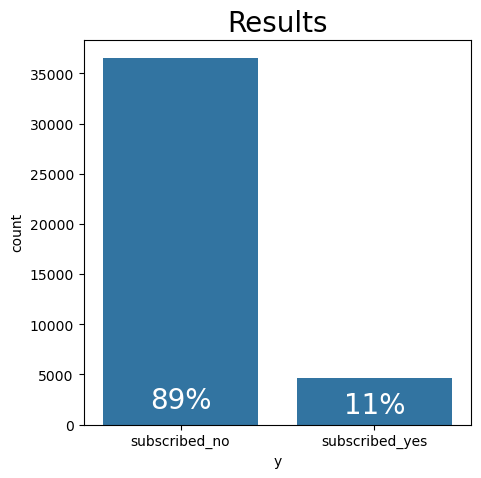

In [8]:
plt.figure(figsize=(5,5))
sns.countplot(x="y", data=bank_df)
percentage_y = bank_df['y'].agg('value_counts', normalize=True) * 100
plt.title("Results", fontsize=20)
plt.tick_params(axis='x', labelsize=10)
plt.text(0,1000, "{:.2g}%".format(percentage_y[0]), ha='center', va='bottom', size=20, color='w')
plt.text(1,500,"{:.2g}%".format(percentage_y[1]), ha='center', va='bottom', size=20, color='w')       
plt.show()

By the results we can check that the data is not balanced. The 'subscribed no' is 8 times the 'subscribed yes'.

### 2.2 SEARCHING FOR CORRELATIONS

#### 2.2.1 INT COLUMNS CORRELATIONS

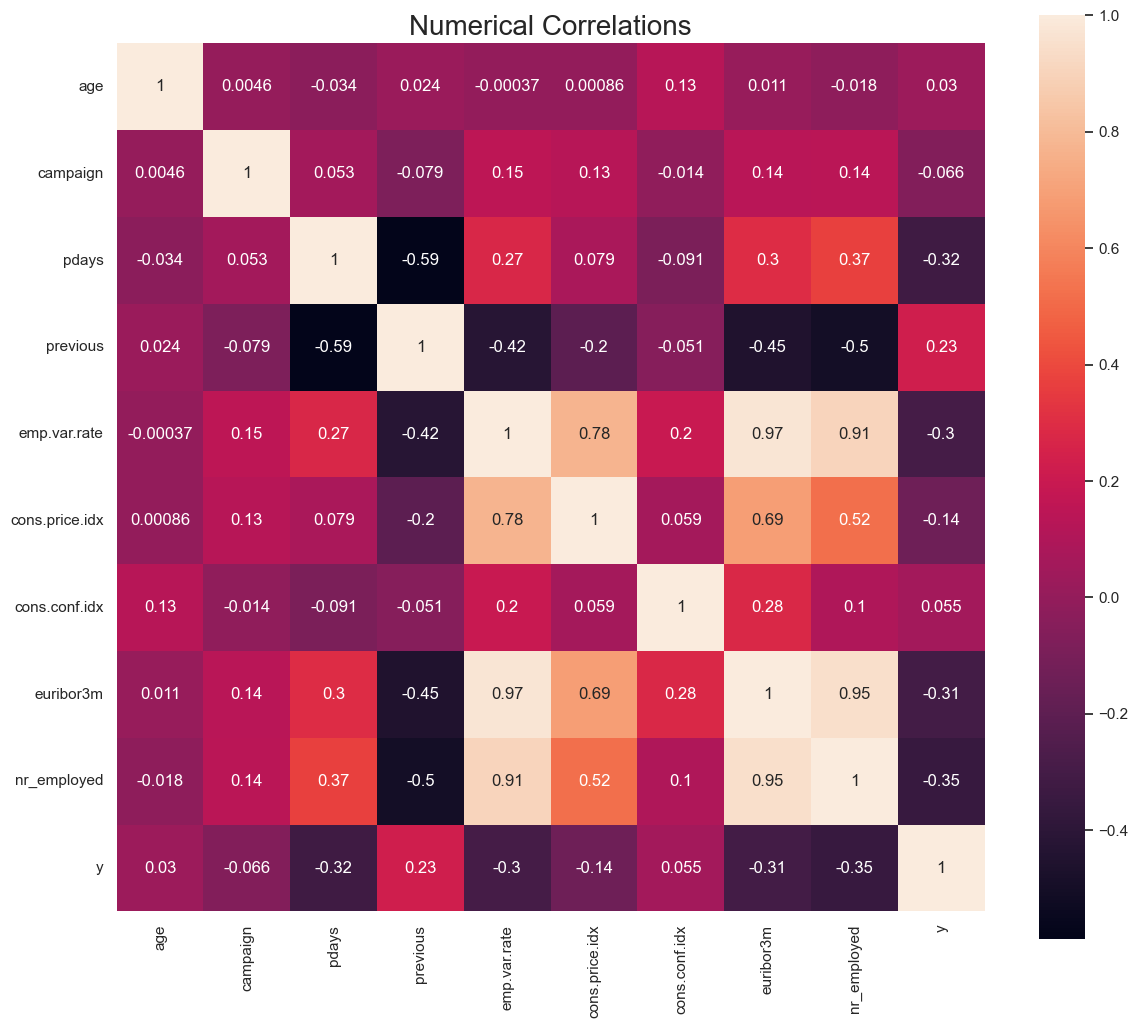

In [9]:
# creating a dataframe copy to manipulate data
bank_df_num = bank_df.copy()

#convert 'y' in 0 or 1
bank_df_num['y'] = bank_df_num['y'].map({'subscribed_yes': 1.0, 'subscribed_no': 0.0})

#create a data with only column type 'numbers'
bank_df_corr_num = bank_df_num.select_dtypes(include=['number'])    

#correlation
matrix_corr_num = bank_df_corr_num.corr()

#heat map
sns.set(rc = {'figure.figsize': (14,12)})
sns.heatmap(matrix_corr_num, square=True, annot=True, xticklabels=matrix_corr_num.columns.values, yticklabels=matrix_corr_num.columns.values)
plt.title("Numerical Correlations",fontsize=20)
plt.show()


HeatMap 'numerical' conclusions:
    - the biggest correlations to 'y' is 'nr_employed' followed by pdays and euribor3m, all in inversal correlations, which means when they increase the probability of 'yes' in 'y' decreased.
    - the strongest positive correlation is 'previous', so if the client was previous contacted it is more likely to accept the offer.
    - the weakest correlation is with 'age', which means 'age' does not influence a lot the 'y' outcome.

#### 2.2.2 OBJECT COLUMNS CORRELATIONS

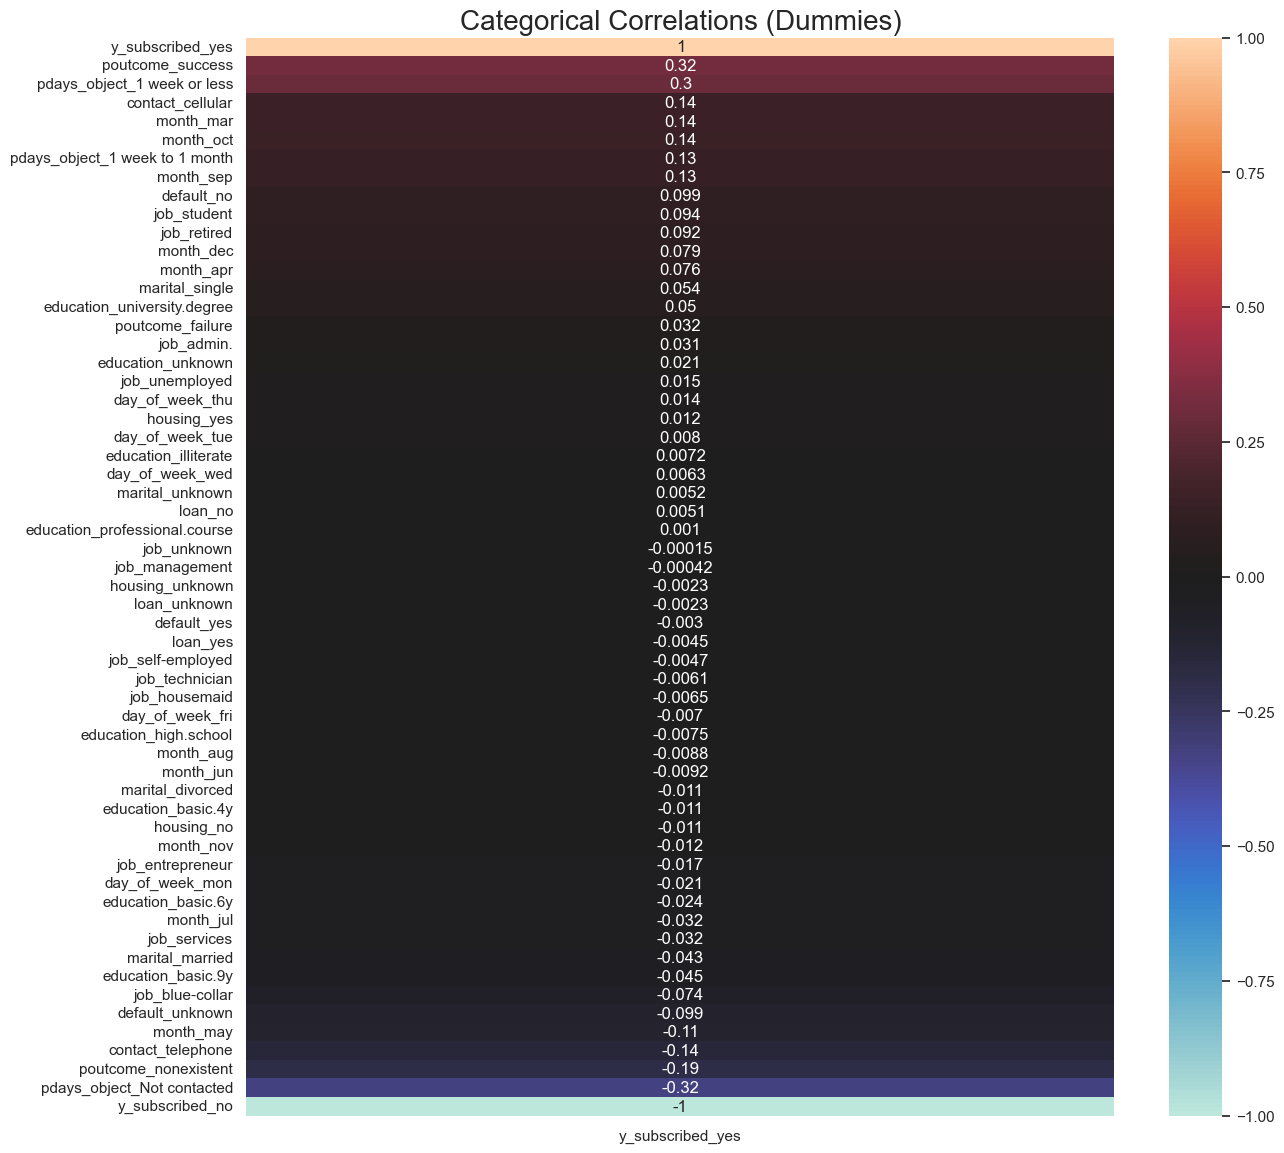

In [10]:
#create a data with only column type 'object'
bank_df_obj = bank_df.select_dtypes(include=['object', 'category'])    

#dummies: transform text in 0 and 1
bank_df_dummies = pd.get_dummies(bank_df_obj)

#correlation
matrix_corr_obj = bank_df_dummies.corr()

# 4. Heatmap for 'subscribed_yes'
plt.figure(figsize=(14, 14))
sns.heatmap(matrix_corr_obj[['y_subscribed_yes']].sort_values(by='y_subscribed_yes', ascending=False), 
            annot=True, center=0)

plt.title("Categorical Correlations (Dummies)",fontsize=20)
plt.show()



HeatMap conclusions 'categorical subscribed_yes':
    - the biggest positive correlations to 'subscribed_yes' are 'poutcome_success' followed by 'pdays_object_1 week or less', which means if before the 'poutcome' of the client was 'success', or the days of last contact where '1 week or less' there is higher probability to the client to say 'yes'.
    - the biggest negative correlations to 'subscribed_yes' are 'pdays_object_Not contacted' followed by 'poutcome_noneexisent', which means if the client was never contacted, or if there is no data about the outcome of the last contact, there is a less probability of get a 'yes' from the client.
    - the weakest correlation is with 'job_unknown'(-0.00015), which means if we do not know the clients job, it almost does not influence at all the outcome of the client to accept or not the product.

### 2.3 VISUALIZATIONS

#### 2.3.1 VISUALIZATIONS 'nr_employed', 'pdays', 'euribor3m', 'previous', 'age', 'emp.var.rate', 'campaign', 'poutcome', 'housing'

In [11]:
# creating a dataframe copy
bank_df_vis = bank_df.copy()

In [12]:
# converting housing and poutcome in numerical
bank_df_vis['housing_numeric'] = bank_df_vis['housing'].map({'no': 0.0, 'unknown': -1, 'yes': 1})
bank_df_vis['poutcome_numeric'] = bank_df_vis['poutcome'].map({'failure': 0, 'nonexistent': -1, 'success': 1})

bank_df_vis.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr_employed,housing_numeric,poutcome_numeric
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.499806,-0.830096
std,10.42125,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.545967,0.455754
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,-1.000000,-1.000000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000,-1.000000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,1.000000,-1.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,1.000000,-1.000000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000,1.000000


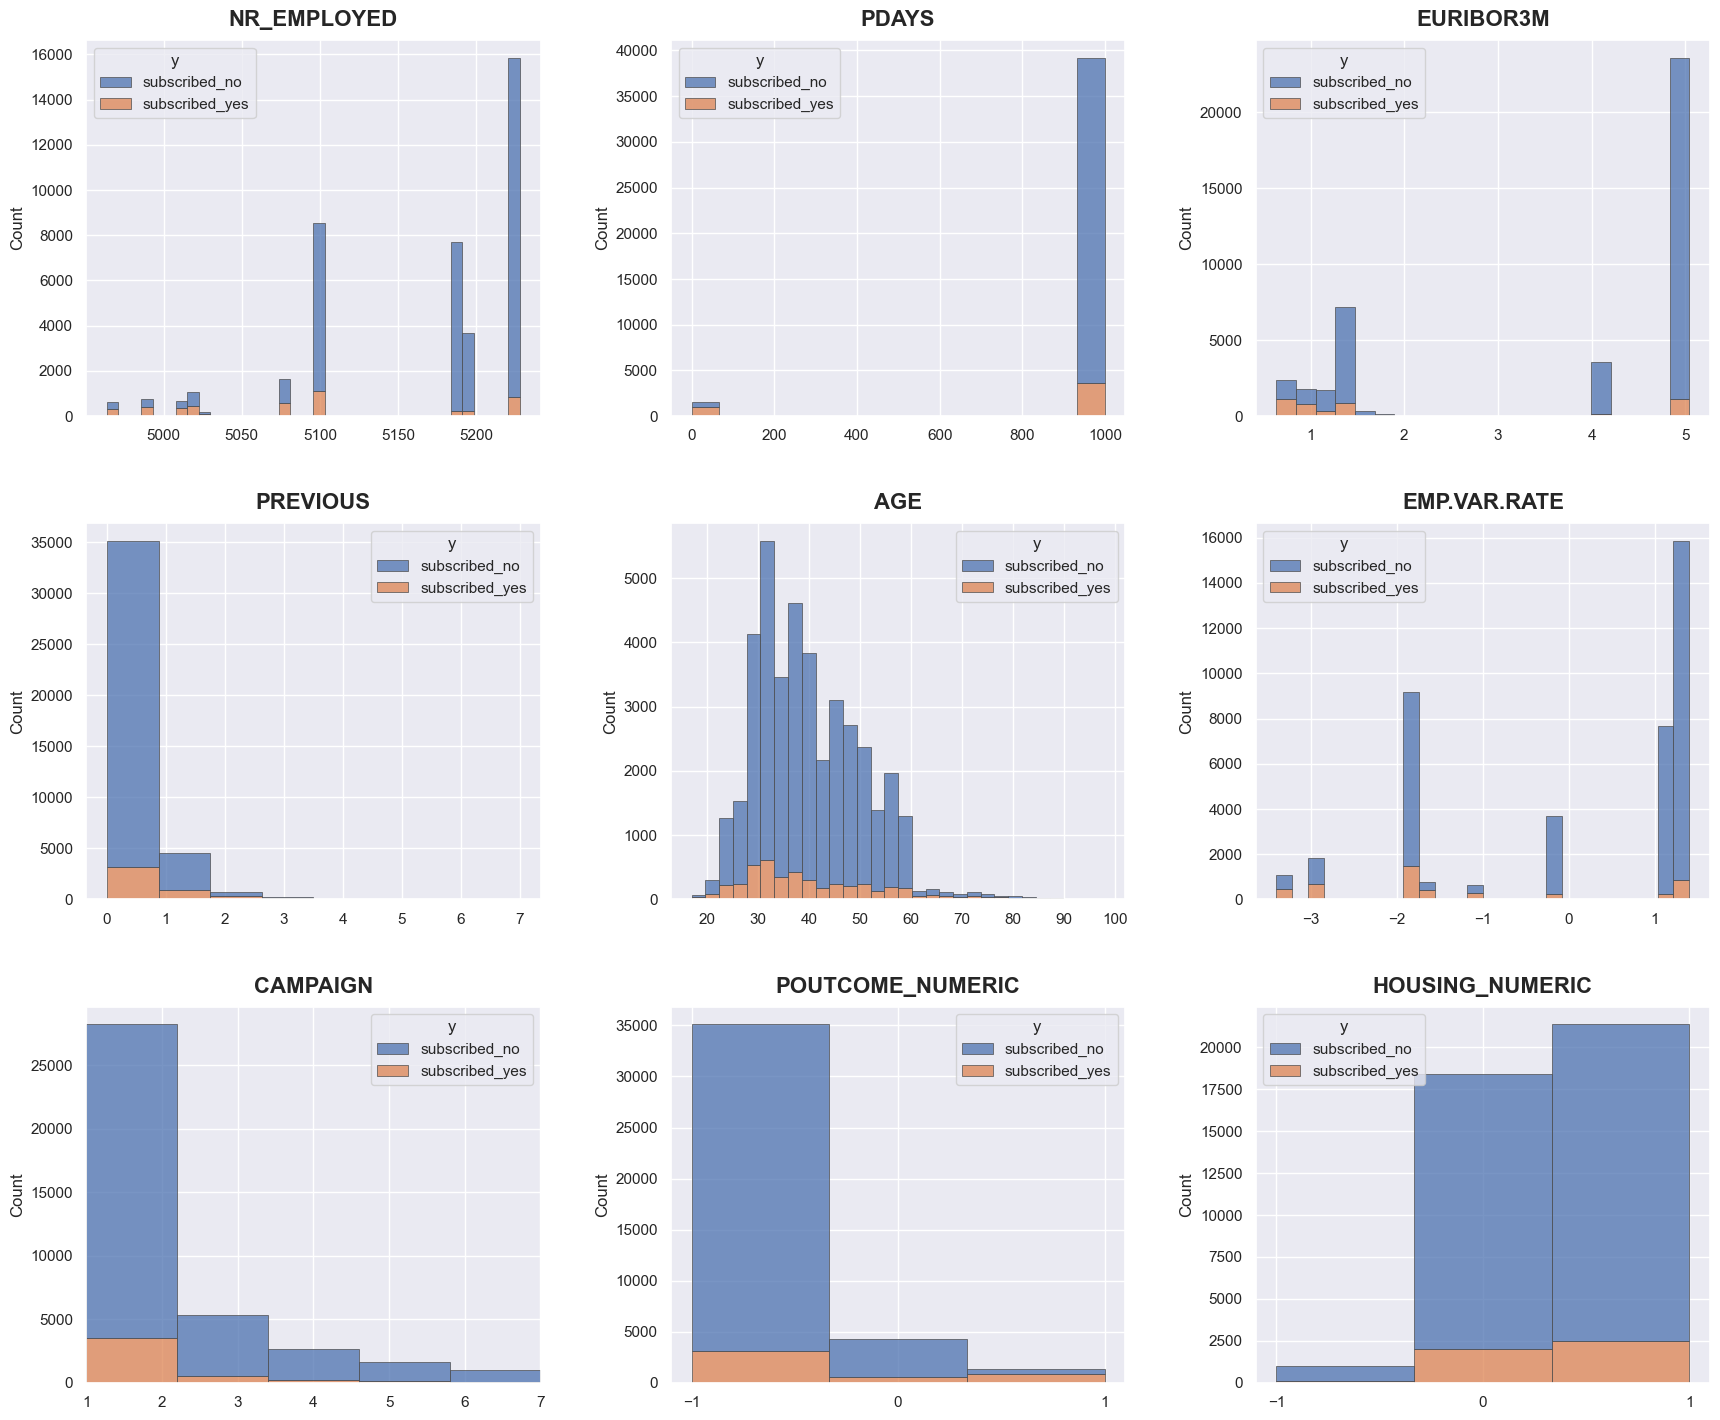

In [13]:
q_campaign = bank_df_vis.campaign.quantile(0.99)
bank_df_vis = bank_df_vis[(bank_df_vis['campaign']<q_campaign)]

int_columns = ['nr_employed', 'pdays', 'euribor3m', 'previous', 'age', 'emp.var.rate', 'campaign', 'poutcome_numeric', 'housing_numeric']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten() # Transform 3x3 matrix in a linear list for loop

for i, column in enumerate(int_columns):
    ax = axes[i]
    # Initialize data_plot as None at the beginning of each loop iteration
    data_plot = None
    
    if column == 'age':
        bins = 30
    elif column == 'campaign':
        ax.set_xlim(1, 7) # Focus on where have more contacts(until 9)
        bins = 10
    elif column == 'pdays':
        bins = 15
    elif column in ['poutcome_numeric', 'housing_numeric', 'previous']:
        # small discrete variables
        bins = len(bank_df_vis[column].unique())
        ax.set_xticks(np.sort(bank_df_vis[column].unique()))
    else:
        # for nr_employed, euribor3m, emp.var.rate (seaborn decide)
        bins = 'auto'

    # Use data_plot only if it's defined (for 'pdays'), otherwise use bank_df_vis
    current_data = data_plot if (column == 'pdays' and data_plot is not None) else bank_df_vis
    
    sns.histplot(
        data=current_data, 
        x=column, 
        hue="y", 
        multiple="stack", 
        bins=bins, 
        ax=ax,
        edgecolor=".3",
        linewidth=.5
    )

    ax.set_title(column.upper(), fontsize=16, fontweight='bold', pad=10)  #title size
    ax.set_xlabel("") # Remove X label 
        
plt.tight_layout(pad=3.0)
plt.show()

By graphs we can deduct that:
    - Best nr_employed is 5100 for efficiency. Increase the number of employes increased the number of calls but not the number of yes from clients.
    - In pdays: the majority of clients where never contact before.
    - In euribor3m: proportionally per call, the clients tend to subscribed more when the euribor is around 1.
    - In previous: the majority of clients had no or fewer contacts before.
    - In age: most of the clients are around 30 years old.
    - In emp.var.rate: the bank gets better results when it is between -3 and -2.
    - In campaign: proportionaly, increasing the calls for the same client does not increase the probabilty of subscription.
    - In poutcome: proportionaly, the clients who subscribed before has more probability to subscribe again, although there is no data about the majority of the clients. 
    - In housing: the majority of clients have a house loan and also subscribed
    

#### 2.3.2 VISUALIZATIONS EURIBOR3M AND NR_EMPLOYED

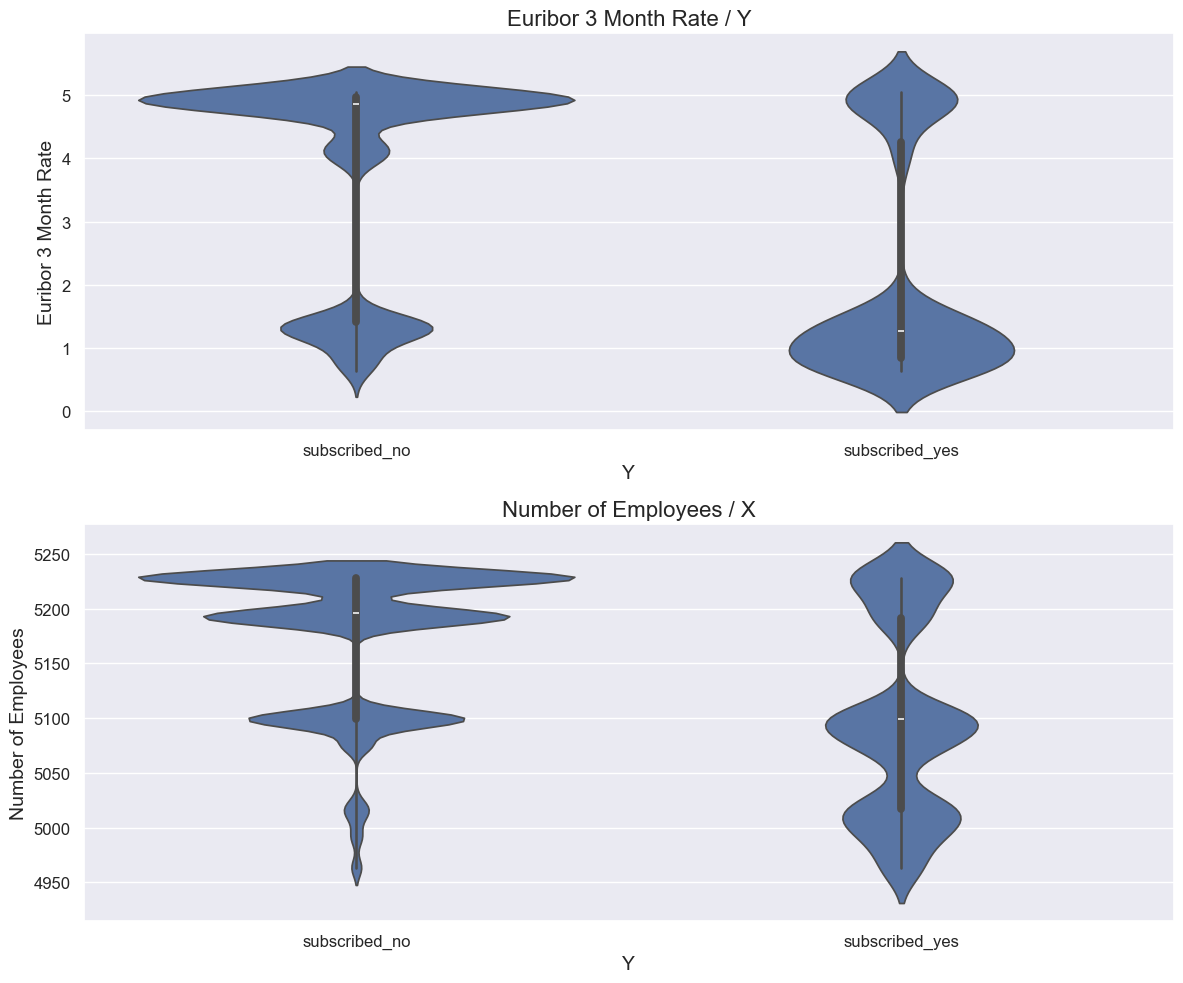

In [14]:
# Create a figure with 2 subplots (one for each continuous variable)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot euribor3m by target variable 'y'
sns.violinplot(data=bank_df_vis, x='y', y='euribor3m', ax=ax1)
ax1.set_title('Euribor 3 Month Rate / Y', fontsize=16)
ax1.set_xlabel('Y', fontsize=14)
ax1.set_ylabel('Euribor 3 Month Rate', fontsize=14)
ax1.tick_params(axis='both', labelsize=12)

# Plot nr_employed by target variable 'y'
sns.violinplot(data=bank_df_vis, x='y', y='nr_employed', ax=ax2)
ax2.set_title('Number of Employees / X', fontsize=16)
ax2.set_xlabel('Y', fontsize=14)
ax2.set_ylabel('Number of Employees', fontsize=14)
ax2.tick_params(axis='both', labelsize=12)

# Adjust layout
plt.tight_layout()
plt.show()

By the graphs we can see a tendency of "subscribed_yes" when the euribor3m is low, while in nr_emplyed it is stable on 5100

#### 2.3.3 AGE VISUALIZATIONS per GROUP

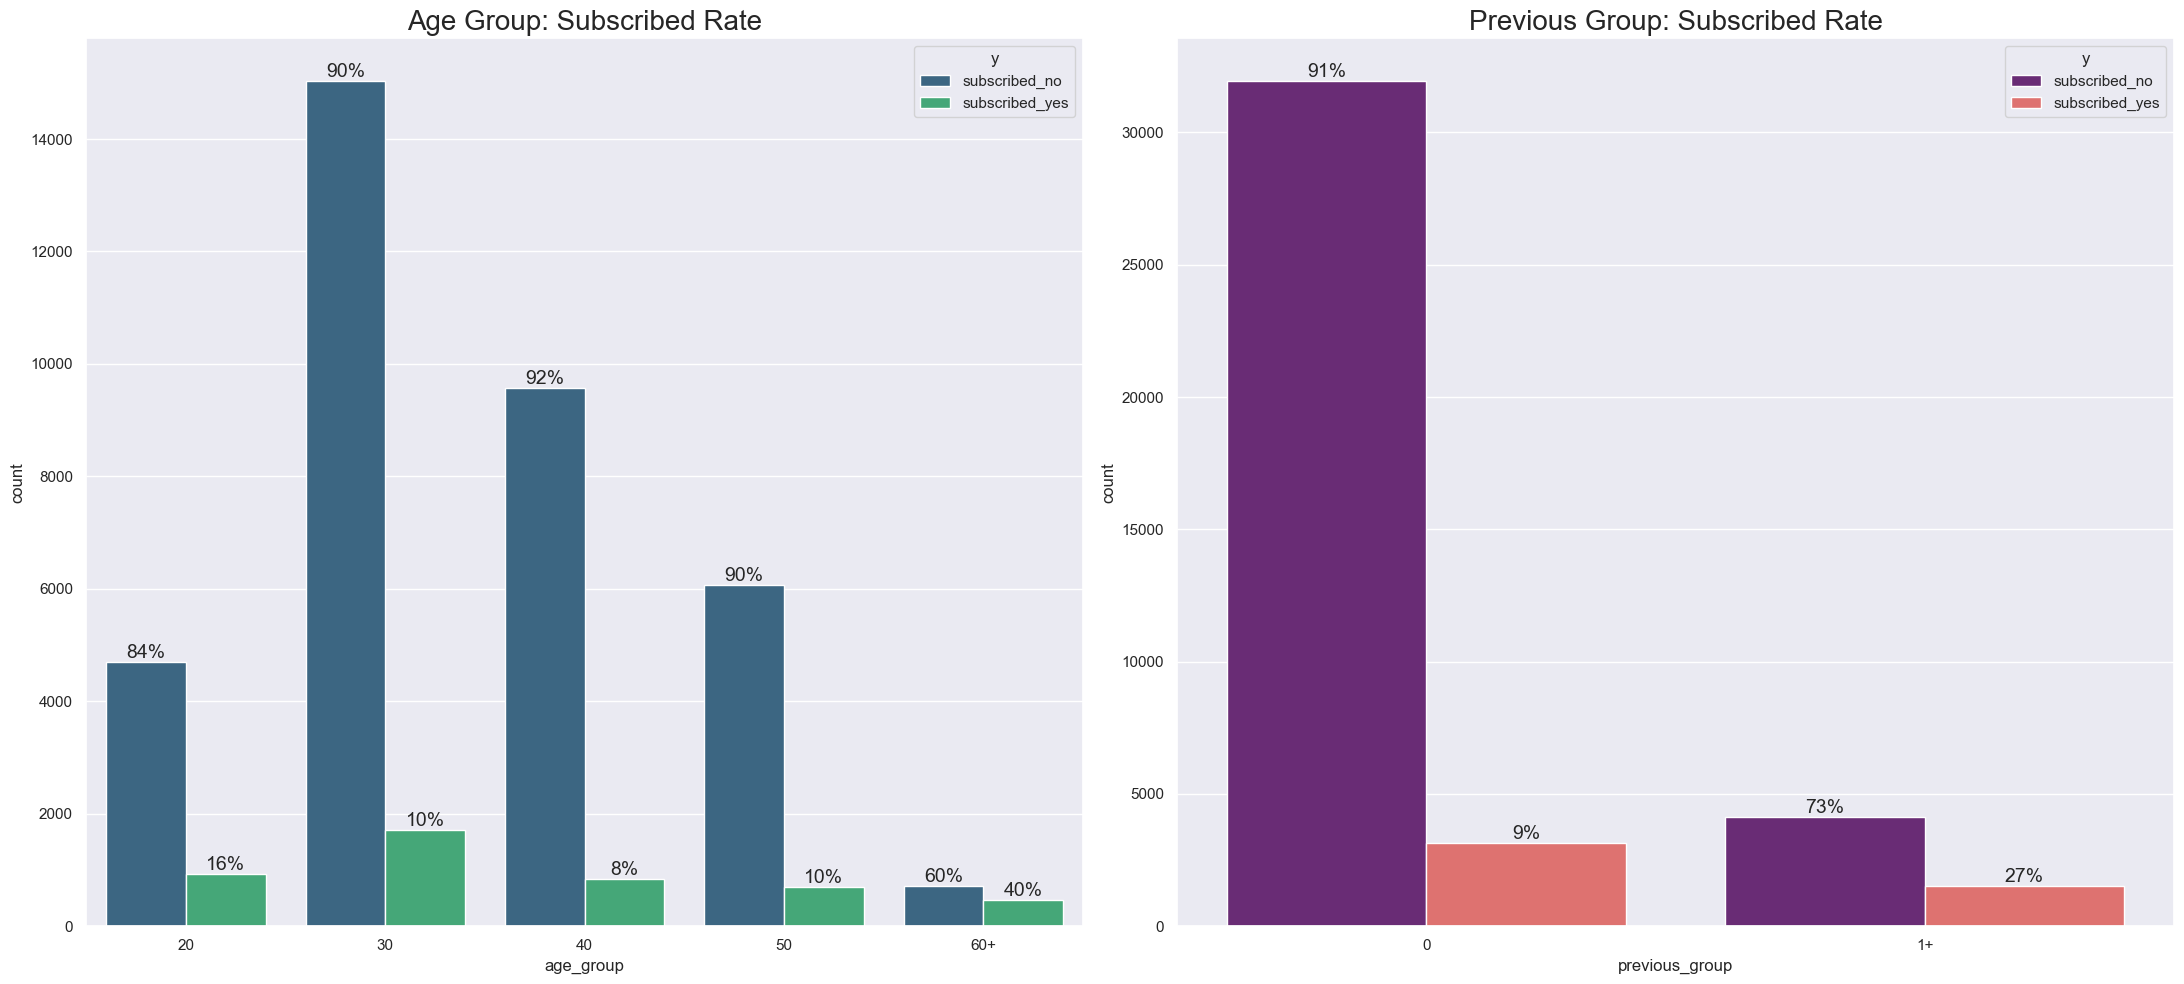

In [15]:
#age group
def create_age_group(age):
    if age < 30: return '20'
    elif age < 40: return '30'
    elif age < 50: return '40'
    elif age < 60: return '50'
    else: return '60+'

bank_df_vis['age_group'] = bank_df_vis['age'].apply(create_age_group)

age_group_y_pct = pd.crosstab(bank_df_vis['age_group'], bank_df_vis['y'], normalize='index') * 100
age_group_num_df = pd.crosstab(bank_df_vis['age_group'], bank_df_vis['y']).reindex(['20', '30', '40', '50', '60+'])

# previous group
bank_df_vis['previous_group'] = np.where(bank_df_vis['previous'] == 0, "0", "1+")

previous_group_y_pct = pd.crosstab(bank_df_vis['previous_group'], bank_df_vis['y'], normalize='index') * 100
previous_group_num_df = pd.crosstab(bank_df_vis['previous_group'], bank_df_vis['y']).reindex(["0", "1+"])


order_list = ['20', '30', '40', '50', '60+']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# Age graph
sns.countplot(x="age_group", hue="y", data=bank_df_vis, order=order_list, ax=ax1, palette='viridis')
ax1.set_title('Age Group: Subscribed Rate', fontsize=20)

for i, group in enumerate(order_list):
    ax1.text(i - 0.2, age_group_num_df.loc[group, 'subscribed_no'], f"{age_group_y_pct.loc[group, 'subscribed_no']:.0f}%", ha='center', va='bottom', fontsize=14)
    ax1.text(i + 0.2, age_group_num_df.loc[group, 'subscribed_yes'], f"{age_group_y_pct.loc[group, 'subscribed_yes']:.0f}%", ha='center', va='bottom', fontsize=14)

# Previous graph
sns.countplot(x="previous_group", hue="y", data=bank_df_vis, order=["0", "1+"], ax=ax2, palette='magma')
ax2.set_title('Previous Group: Subscribed Rate', fontsize=20)

for i, group in enumerate(["0", "1+"]):
    ax2.text(i - 0.2, previous_group_num_df.loc[group, 'subscribed_no'], f"{previous_group_y_pct.loc[group, 'subscribed_no']:.0f}%", ha='center', va='bottom', fontsize=14)
    ax2.text(i + 0.2, previous_group_num_df.loc[group, 'subscribed_yes'], f"{previous_group_y_pct.loc[group, 'subscribed_yes']:.0f}%", ha='center', va='bottom', fontsize=14)

plt.tight_layout()
plt.show()

#### 2.3.4 AGE/CAMPAIGN VISUALIZATIONS per GROUP

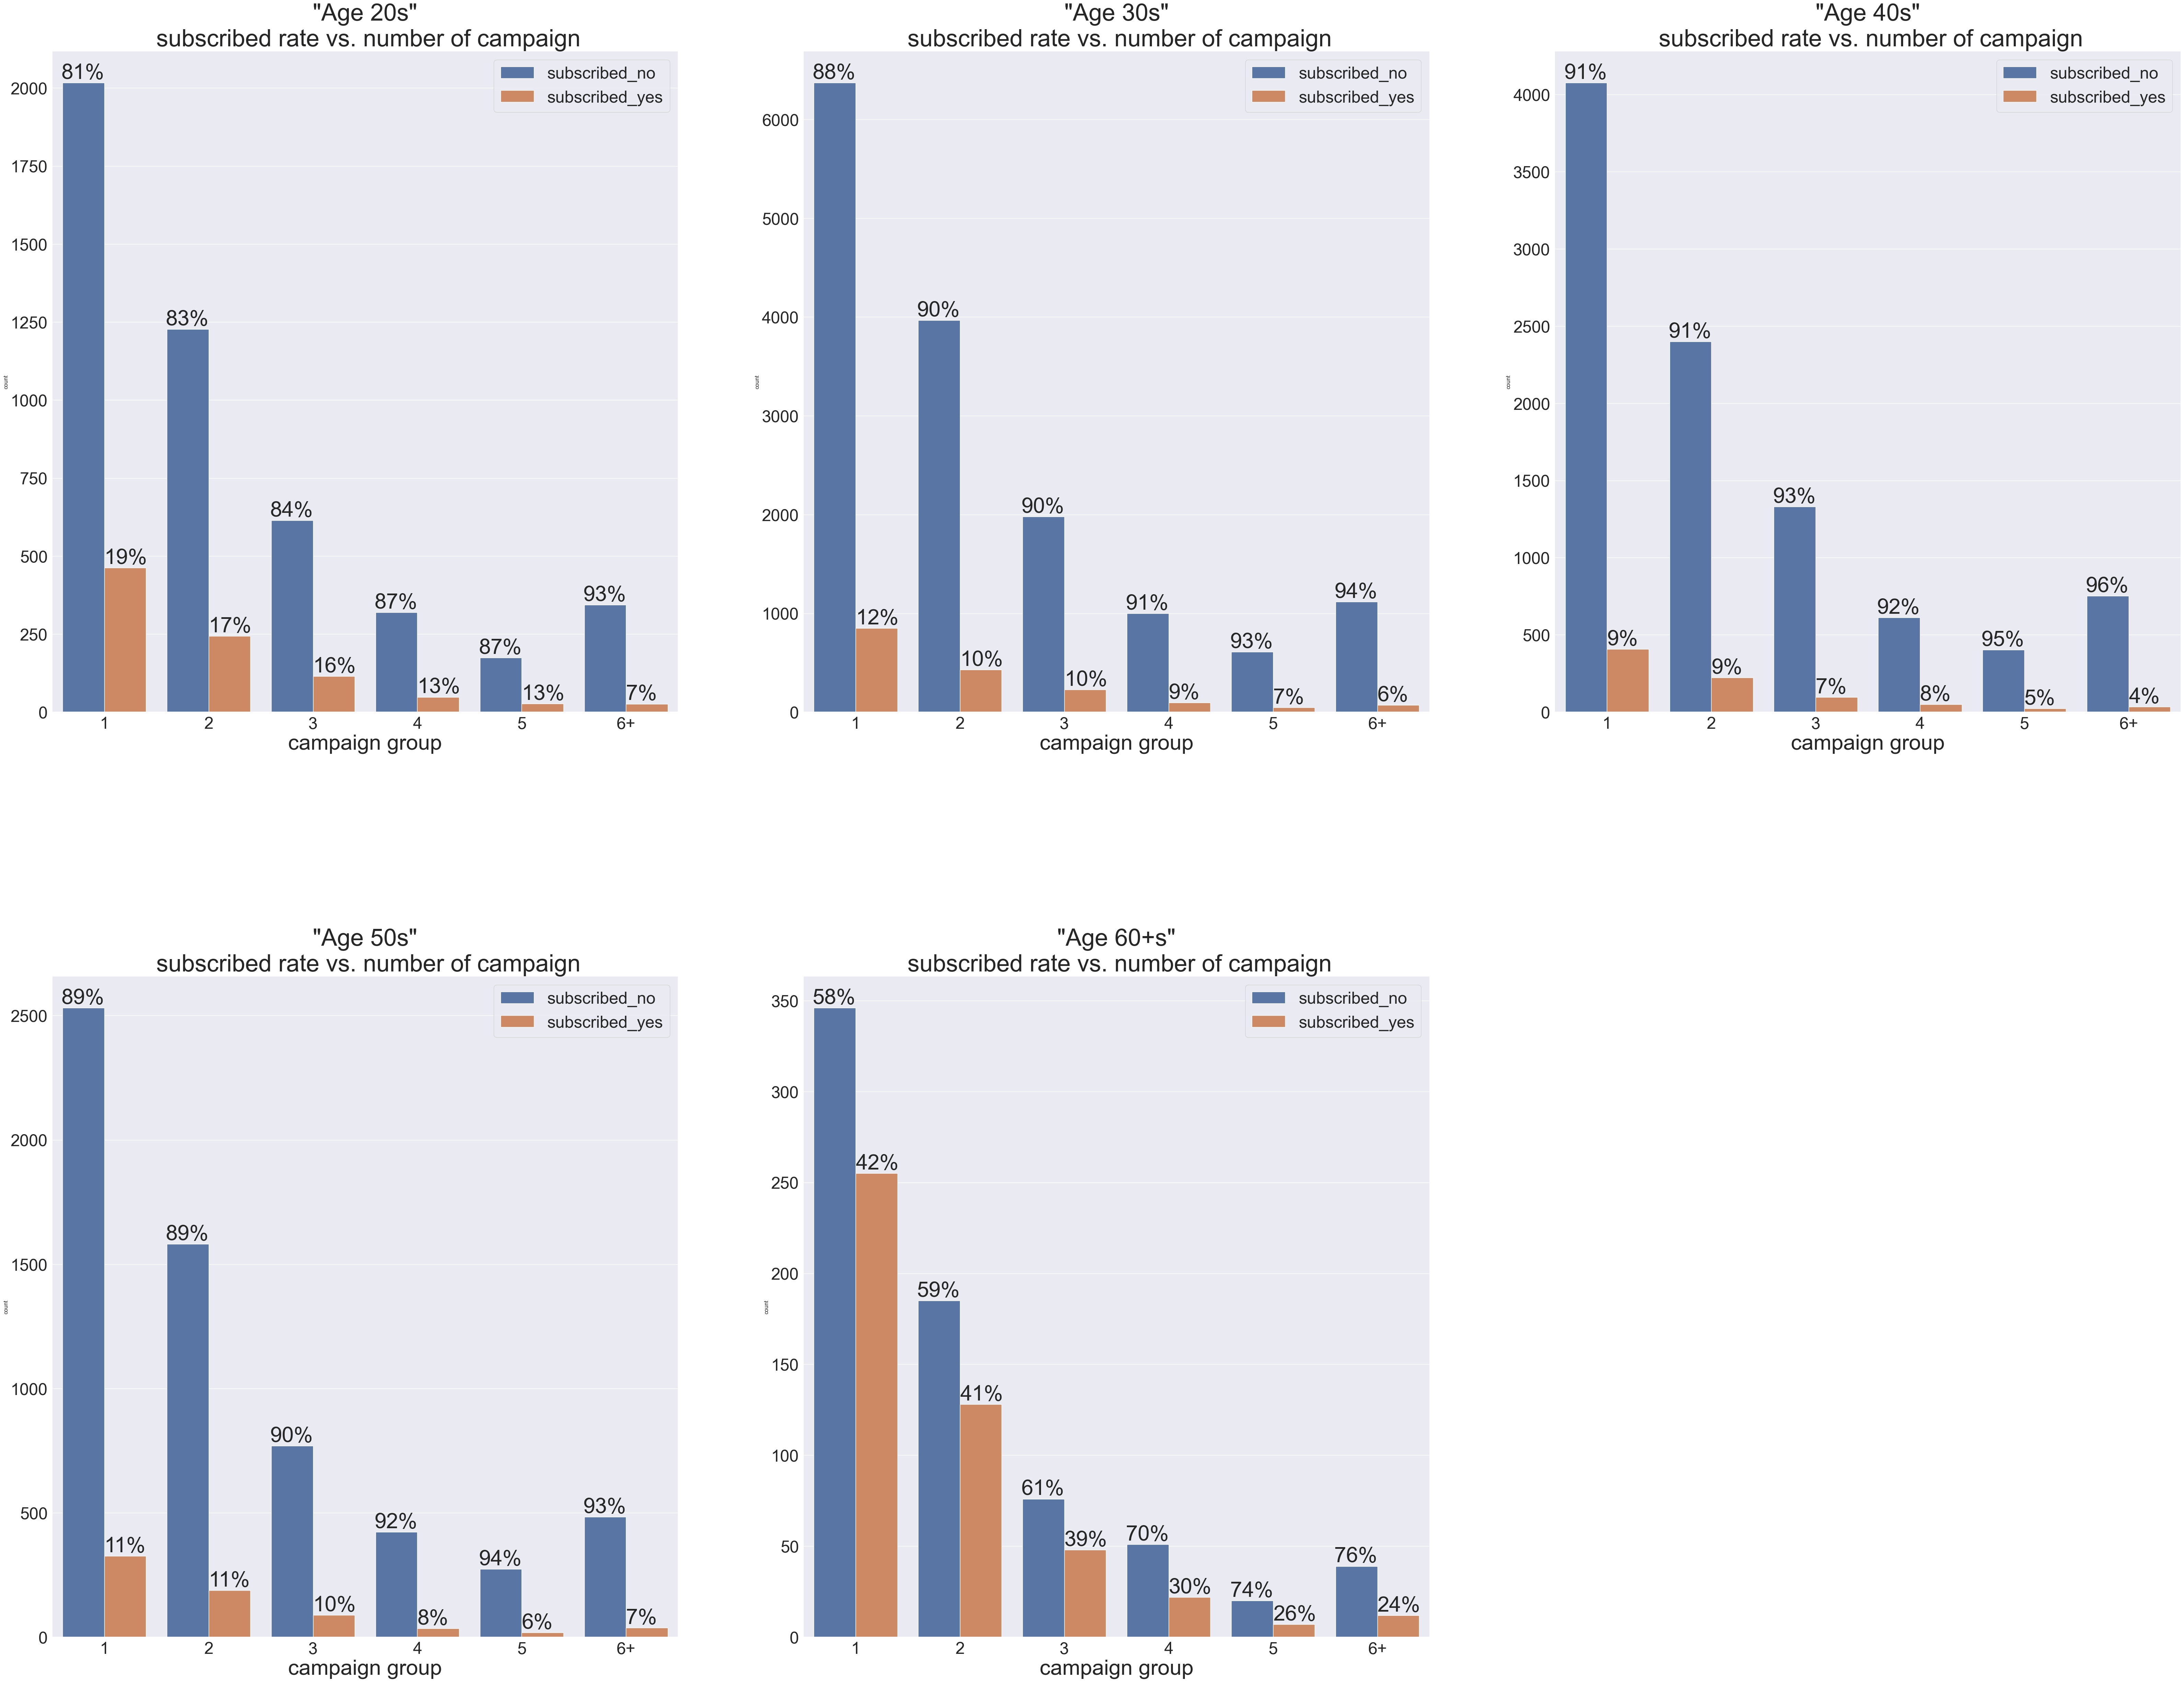

In [16]:
# Automatic max limit
max_y = ax.get_ylim()[1] 
ticks = np.linspace(0, max_y, 6).astype(int)
ax.set_yticks(ticks)


# Create the campaign_group column
bank_df_vis['campaign_group'] = '6+'  # Default value
bank_df_vis.loc[bank_df_vis["campaign"] == 1, 'campaign_group'] = '1'
bank_df_vis.loc[bank_df_vis["campaign"] == 2, 'campaign_group'] = '2'
bank_df_vis.loc[bank_df_vis["campaign"] == 3, 'campaign_group'] = '3'
bank_df_vis.loc[bank_df_vis["campaign"] == 4, 'campaign_group'] = '4'
bank_df_vis.loc[bank_df_vis["campaign"] == 5, 'campaign_group'] = '5'
bank_df_vis.loc[bank_df_vis["campaign"] > 5, 'campaign_group'] = '6+'

fig = plt.figure(figsize=(80,60))
age_list = ['20','30','40','50','60+']
campaign_list = ['1','2','3','4','5','6+']

for i,age in enumerate(age_list):
    bank_age_group = bank_df_vis[bank_df_vis['age_group'] == age]

    campaign_group_y_pct = pd.crosstab(bank_age_group['y'],bank_age_group['campaign_group']).apply(lambda x: x/x.sum() * 100)
    campaign_group_y_pct = campaign_group_y_pct.transpose() 

    campaign_group_num_or_sum_df = pd.DataFrame()
    campaign_group_num_or_sum_df = pd.crosstab(bank_age_group['campaign_group'], bank_age_group['y']).reindex(index=campaign_list)

    ax = fig.add_subplot(2,3, i + 1)

    age_group_df = bank_df_vis[bank_df_vis['age_group'] == age]
    sns.countplot(x="campaign_group", hue="y", data=age_group_df, order=campaign_list, ax=ax)

    ax.set_xlabel('campaign group',fontsize=45, y=0.5)
    ax.tick_params(axis='x', labelsize=35)
    ax.tick_params(axis='y', labelsize=35)
    ax.set_title('"Age {}s"\n subscribed rate vs. number of campaign'.format(age),fontsize =50)
    ax.legend(fontsize=35)
    
    for j,campaign_group in enumerate(campaign_group_num_or_sum_df.index):
        # Changed i to j to avoid overwriting the outer loop variable
        plt.text(j, campaign_group_num_or_sum_df.loc[campaign_group, 'subscribed_yes'], "{}%".format(round(campaign_group_y_pct.loc[campaign_group, 'subscribed_yes'])),  ha='left', va='bottom', size=45)
        plt.text(j, campaign_group_num_or_sum_df.loc[campaign_group, 'subscribed_no'], "{}%".format(round(campaign_group_y_pct.loc[campaign_group, 'subscribed_no'])),  ha='right', va='bottom', size=45)
plt.subplots_adjust(hspace=0.4)
plt.show()

#### 2.3.5 VISUALIZATION CATEGORICAL COLUMNS

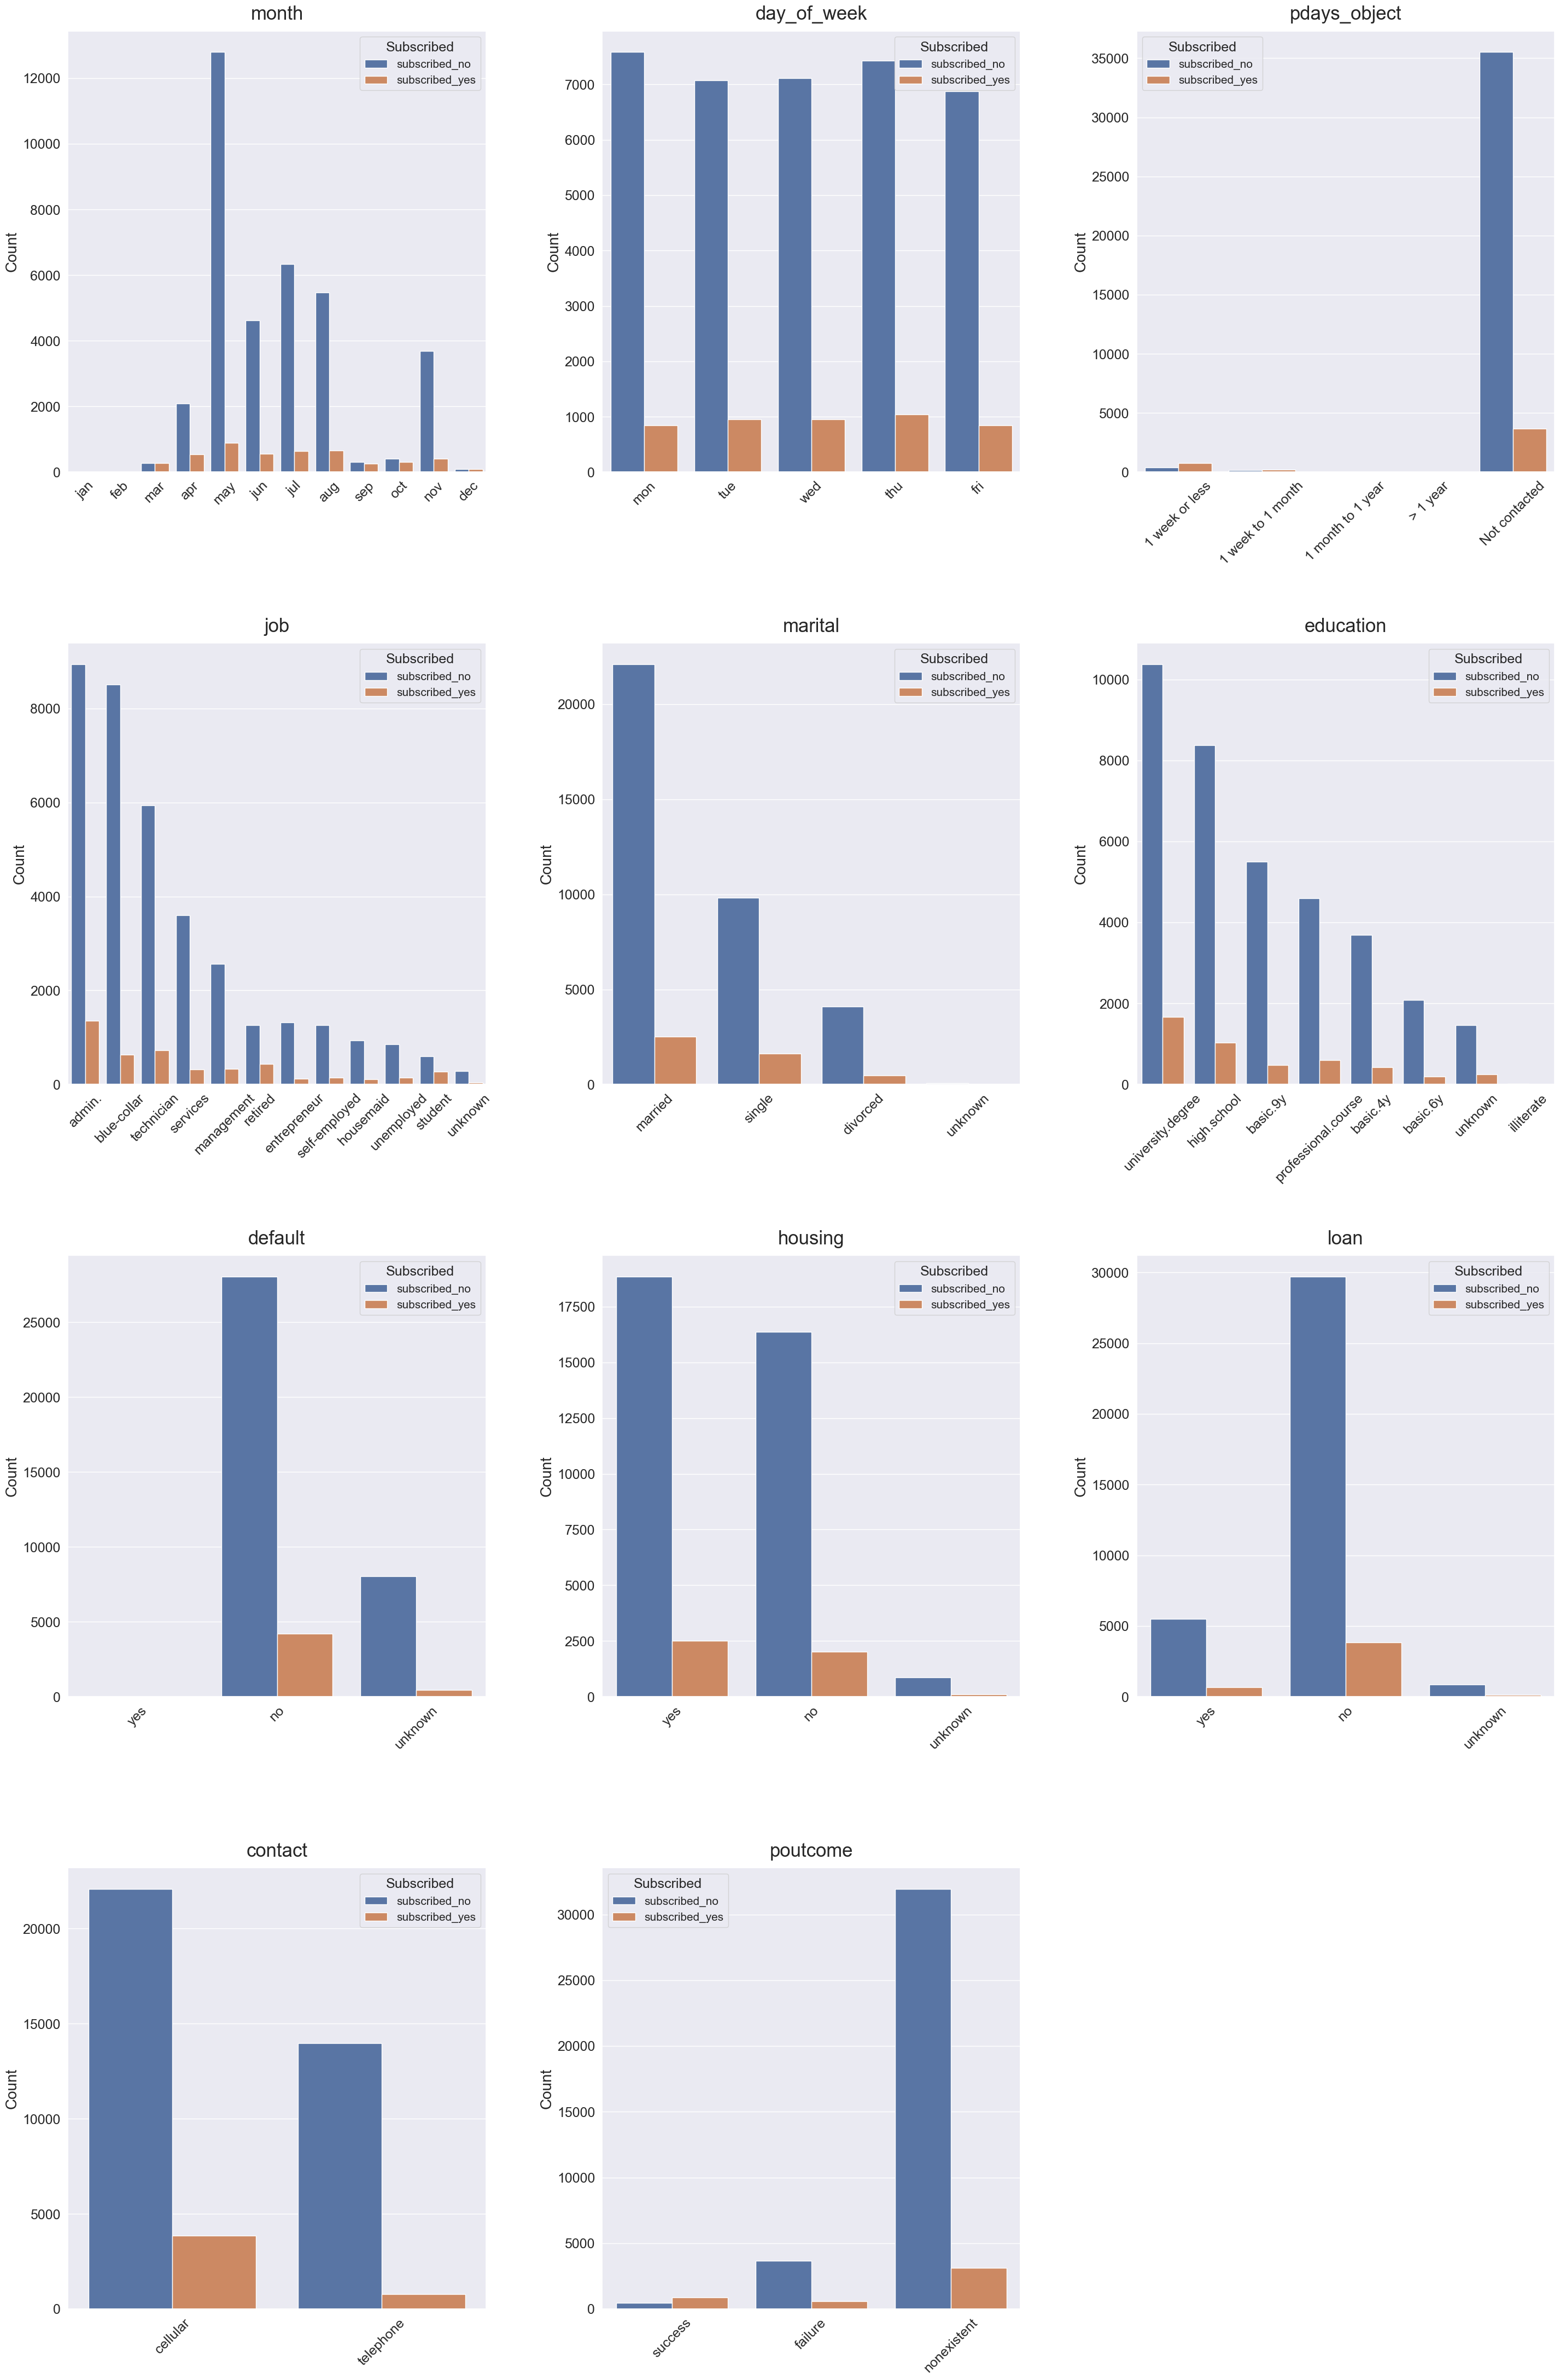

In [17]:
# CREATING categories
order_month = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
order_day_of_week = ['mon','tue','wed','thu','fri']
order_pdays = ['1 week or less','1 week to 1 month','1 month to 1 year','> 1 year','Not contacted']
yes_no_columns = ['default','housing','loan']

categorical_columns = ['month','day_of_week', 'pdays_object','job','marital','education','default','housing','loan','contact','poutcome']

fig = plt.figure(figsize=(30, 45)) 

for i, column in enumerate(categorical_columns):
    ax = fig.add_subplot(4, 3, i + 1)
    if column == 'month':
        order = order_month
    elif column == 'day_of_week':
        order = order_day_of_week
    elif column == 'pdays_object':
        order = order_pdays
    elif column in yes_no_columns:
        order = ['yes', 'no', 'unknown']
    elif column == 'poutcome':
        order = ['success', 'failure', 'nonexistent']
    else:
        # order by biggest frequency
        order = bank_df_vis[column].value_counts().index.tolist()

    # graph creation
    sns.countplot(x=column, hue="y", data=bank_df_vis, ax=ax, order=order)
    
    ax.set_title(f'{column}', fontsize=25, pad=15)
    ax.tick_params(axis='x', labelsize=18, rotation=45)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=20)
    ax.legend(title='Subscribed', fontsize=15, title_fontsize=18)

plt.tight_layout(pad=5.0)
plt.show()

#### 2.3.6 VISUALIZATION HOUSING/LOAN PER Y

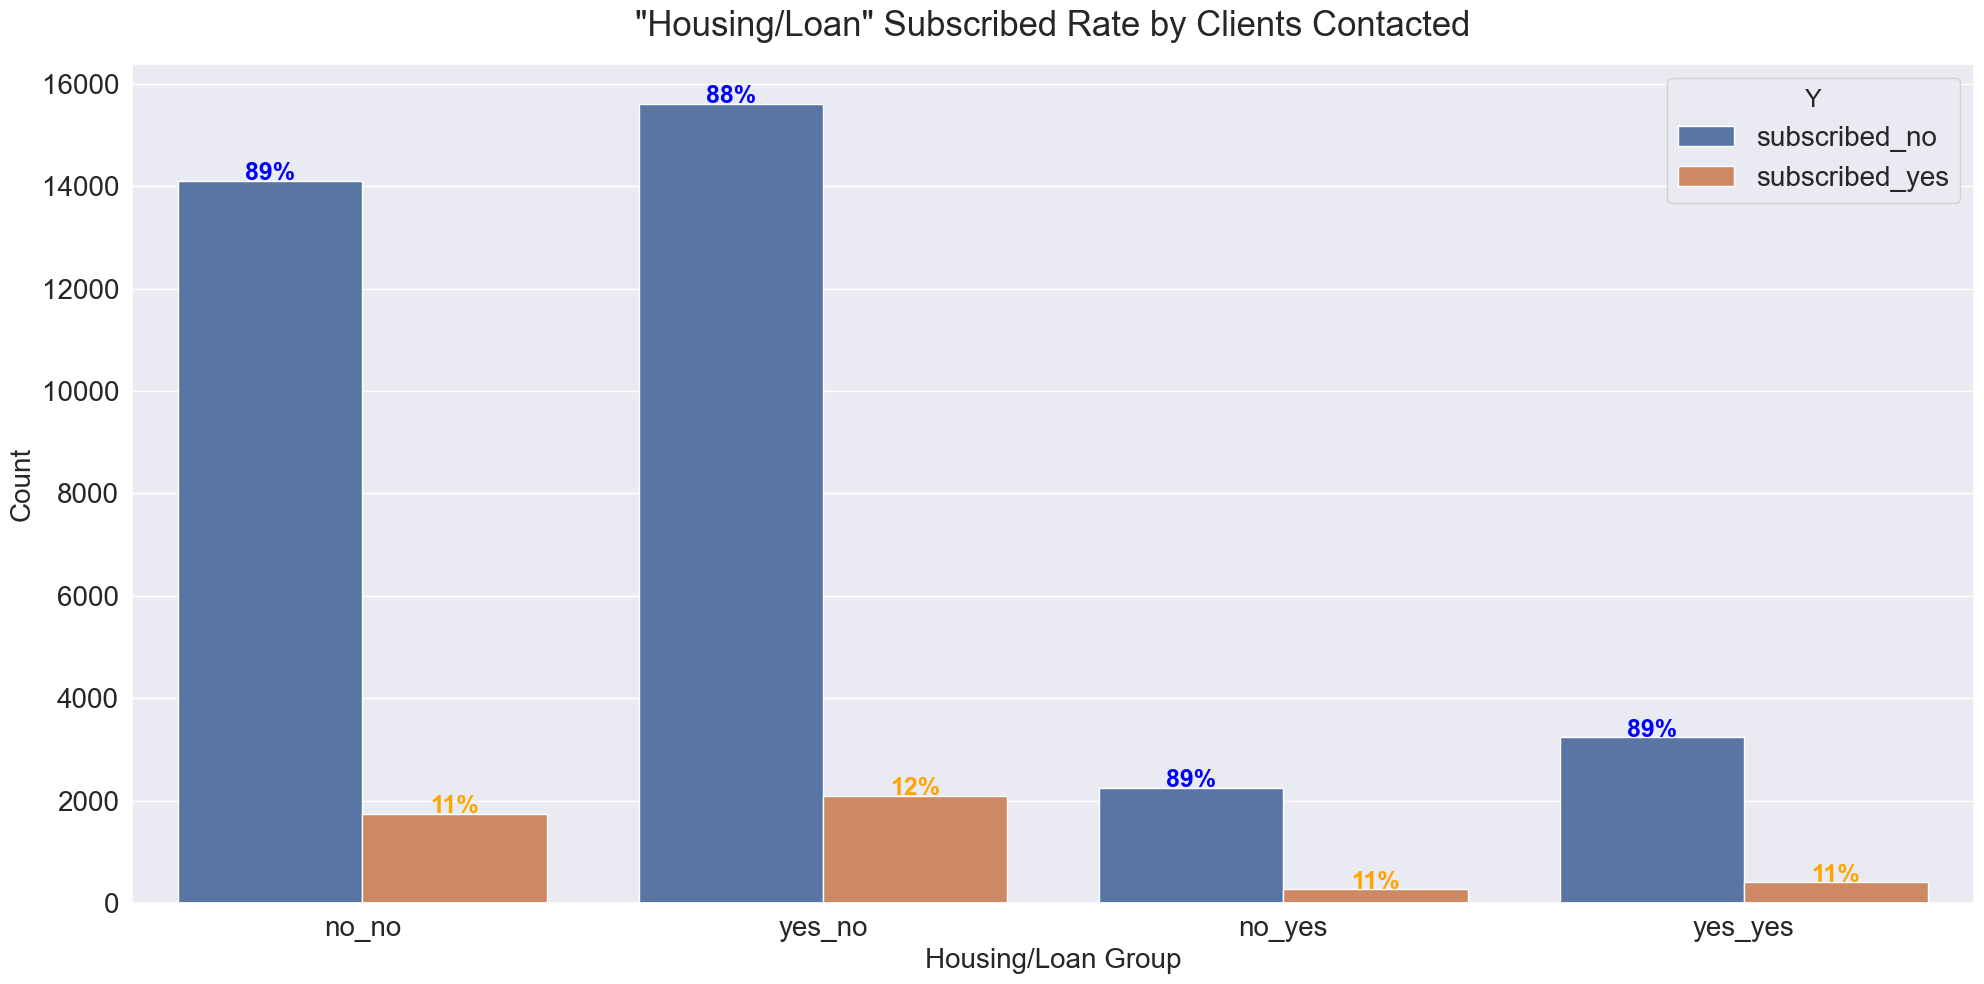

In [18]:
# UNION HOUSING AND LOAN
bank_df_vis['housing_and_loan'] = bank_df_vis['housing'] + "_" + bank_df_vis['loan']

# IN PERCENTAGE
count_pct = pd.crosstab(bank_df_vis['housing_and_loan'], bank_df_vis['y'], normalize='index') * 100

# Total
count_sum = pd.crosstab(bank_df_vis['housing_and_loan'], bank_df_vis['y'])

# order
order_hl = ['no_no', 'yes_no', 'no_yes', 'yes_yes']
order_hl = [x for x in order_hl if x in count_sum.index]

plt.figure(figsize=(20, 10))

sns.countplot(x="housing_and_loan", hue="y", data=bank_df_vis, order=order_hl) 

for i, group in enumerate(order_hl):
    height_yes = count_sum.loc[group, 'subscribed_yes']
    height_no = count_sum.loc[group, 'subscribed_no']
    
    pct_yes = count_pct.loc[group, 'subscribed_yes']
    pct_no = count_pct.loc[group, 'subscribed_no']
    
    plt.text(i + 0.2, height_yes + 10, f"{round(pct_yes)}%", 
             ha='center', size=18, fontweight='bold', color='orange')
    
    plt.text(i - 0.2, height_no + 10, f"{round(pct_no)}%", 
             ha='center', size=18, fontweight='bold', color='blue')

plt.title('"Housing/Loan" Subscribed Rate by Clients Contacted', fontsize=25, pad=20)
plt.xlabel('Housing/Loan Group', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.tick_params(axis='both', labelsize=20)
plt.legend(title='Y', fontsize=20, title_fontsize=18)

plt.tight_layout()
plt.show()

## 3. FEATURE ENGINEERING

### 3.1 Dummy variables

In [19]:
bank_df_fe = bank_df_raw.copy()
bank_df_fe

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [20]:
#In target value, 'yes' to '1', 'no' to '0' 
def y_num(y):
    if y == 'yes':
        return 1
    else:
        return 0
bank_df_fe['y'] = bank_df_fe['y'].apply(y_num)


In [21]:
def loan_num(loan):
    if loan == 'yes':
        return 1
    else:
        return 0
bank_df_fe['loan'] = bank_df_fe['loan'].apply(loan_num)

In [22]:
def housing_num(housing):
    if housing == 'yes':
        return 1
    else:
        return 0
bank_df_fe['housing'] = bank_df_fe['housing'].apply(housing_num)

In [23]:
def poutcome_num(poutcome):
    if poutcome == 'success':
        return 1
    else:
        if poutcome == 'nonexistent':
            return 1
        else:
            return 0
bank_df_fe['poutcome'] = bank_df_fe['poutcome'].apply(poutcome_num)

In [24]:
def month_to_num(month):
    if month == 'jan':
       return 1
    elif month == 'feb':
       return 2
    elif month == 'mar':
       return 3
    elif month == 'apr':
       return 4
    elif month == 'may':
       return 5
    elif month == 'jun':
       return 6
    elif month == 'jul':
       return 7
    elif month == 'aug':
       return 8
    elif month == 'sep':
       return 9
    elif month == 'oct':
       return 10
    elif month == 'nov':
       return 11
    else:
       return 12

bank_df_fe['month'] = bank_df_fe['month'].apply(month_to_num)

In [25]:
bank_df_fe

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,0,0,telephone,5,mon,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,0,0,telephone,5,mon,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,1,0,telephone,5,mon,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,0,0,telephone,5,mon,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,0,1,telephone,5,mon,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,1,0,cellular,11,fri,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41184,46,blue-collar,married,professional.course,no,0,0,cellular,11,fri,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,retired,married,university.degree,no,1,0,cellular,11,fri,2,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44,technician,married,professional.course,no,0,0,cellular,11,fri,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1


In [26]:
bank_df_fe = pd.get_dummies(bank_df_fe)
bank_df_fe

,age,housing,loan,month,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,...,default_no,default_unknown,default_yes,contact_cellular,contact_telephone,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed
0,56,0,0,5,1,999,0,1,1.1,93.994,...,True,False,False,False,True,False,True,False,False,False
1,57,0,0,5,1,999,0,1,1.1,93.994,...,False,True,False,False,True,False,True,False,False,False
2,37,1,0,5,1,999,0,1,1.1,93.994,...,True,False,False,False,True,False,True,False,False,False
3,40,0,0,5,1,999,0,1,1.1,93.994,...,True,False,False,False,True,False,True,False,False,False
4,56,0,1,5,1,999,0,1,1.1,93.994,...,True,False,False,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,1,0,11,1,999,0,1,-1.1,94.767,...,True,False,False,True,False,True,False,False,False,False
41184,46,0,0,11,1,999,0,1,-1.1,94.767,...,True,False,False,True,False,True,False,False,False,False
41185,56,1,0,11,2,999,0,1,-1.1,94.767,...,True,False,False,True,False,True,False,False,False,False
41186,44,0,0,11,1,999,0,1,-1.1,94.767,...,True,False,False,True,False,True,False,False,False,False


### 3.2 TRAIN TEST SPLIIT

In [27]:
# Separate X e y
y = bank_df_fe['y']
X = bank_df_fe.drop('y', axis=1)

# I decided to put 80% for (training+Val) and 20% for final test as usual
# 1st division, 'stratify=y' because there is alot 'no', stratify makes sure there is equal proportion of 'yes' for training, val and test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

# 2nd division, I take 20% from de initial 80% for validation(16% total)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=0, stratify=y_train_val)

print(f"TRAIN: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")


TRAIN: 26360 samples
Validation: 6590 samples
Test: 8238 samples


### 3.3 DROP CAMPAIGN OUTLIERS (only one that need to drop outliers from previous visualizations)

In [28]:
# cleanning campaign
Q1 = X_train['campaign'].quantile(0.25)
Q3 = X_train['campaign'].quantile(0.75)
IQR = Q3 - Q1
max_campaign = Q3 + 1.5 * IQR
X_train = X_train[X_train['campaign'] < max_campaign]
y_train = y_train.loc[X_train.index] 

print(f"X lines: {X_train.shape[0]}")
print(f"y lines: {y_train.shape[0]}")

X_train[['campaign']].describe()

X lines: 24184
y lines: 24184


,campaign
count,24184.000000
mean,1.946039
std,1.125036
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,5.000000


### 3.3 FIXING IMBALANCED DATA

In [29]:
y_train.value_counts()     # count how many yes and no are in the training

y
0    21335
1     2849
Name: count, dtype: int64

In [30]:
y_val.value_counts()     # count how many yes and no are in the validation

y
0    5848
1     742
Name: count, dtype: int64

In [31]:
y_test.value_counts()      # count how many yes and no are in the test

y
0    7310
1     928
Name: count, dtype: int64

In [32]:
# create artificial 'yes' to have 50/50 data 'yes' and 'no'
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [33]:
# VERIFICATION
y_train_sm.value_counts()

y
0    21335
1    21335
Name: count, dtype: int64

## 4. ML MACHINE LEARNING

In [34]:
def plot_confusion_matrix(data, labels):
    sns.set(color_codes=True)
    plt.figure(1, figsize=(12, 8))
 
    plt.title("Confusion Matrix",  fontsize=18)
 
    sns.set(font_scale=1.4)
    ax = sns.heatmap(data, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Scale'}, fmt="d")
 
    ax.set_xticklabels(labels, fontsize=18)
    ax.set_yticklabels(labels, fontsize=18)
 
    ax.set_xlabel("Predicted Label",fontsize=18)
    ax.set_ylabel("True Label",fontsize=18)

def subscribed_yes_no(y):
    if y == 1:
        return 'subscribed_yes'
    else:
        return 'subscribed_no'

labels = ['subscribed no','subscribed yes']

### 4.1 RANDOM FOREST CLASSIFIER

In [35]:
#DEFINE parameters
best_xgb = None
params = {
    'criterion'   : ['gini', 'entropy'],
    'n_estimators': [ 50, 100, 200, 400, 600],
    'max_depth'   : [ 1, 5, 10, 15]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(rf, param_grid=params, cv=5, n_jobs = 4, scoring='roc_auc', verbose=1)   #cv=numero de treinos,importante é o AUC, verbose =2 para o python mostrar o que esta a fazer
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 400}


In [36]:
# I decided to create a THRESHOLD variable, so then I can easily change it for better marketing plan
y_probs = best_rf.predict_proba(X_test)[:, 1] 
novo_threshold = 0.3
y_pred_final = (y_probs >= novo_threshold).astype(int)

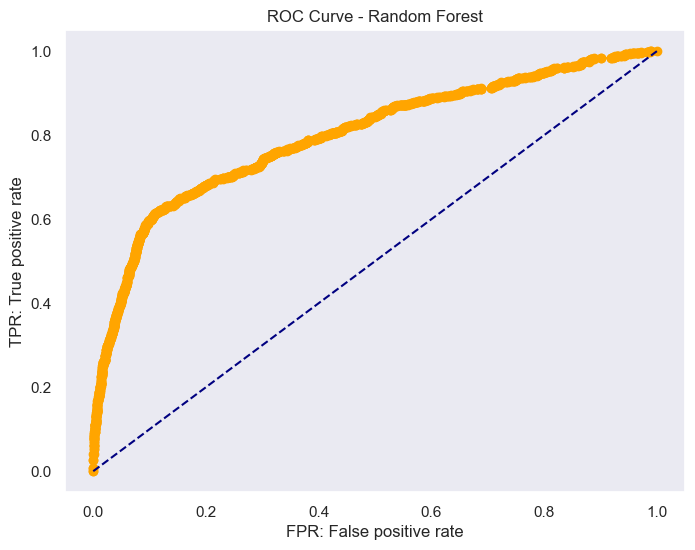

                precision    recall  f1-score   support

 subscribed_no       0.94      0.93      0.93      7310
subscribed_yes       0.47      0.49      0.48       928

      accuracy                           0.88      8238
     macro avg       0.70      0.71      0.71      8238
  weighted avg       0.88      0.88      0.88      8238

AUC : 0.7991


In [37]:
fpr_all, tpr_all, th_all = me.roc_curve(y_test, y_probs, pos_label=1)

plt.figure(figsize=(8,6))
plt.plot(fpr_all, tpr_all, marker='o', color='orange')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('FPR: False positive rate')
plt.ylabel('TPR: True positive rate')
plt.title('ROC Curve - Random Forest')
plt.grid()
plt.show()

print(classification_report(y_test, y_pred_final, target_names=['subscribed_no', 'subscribed_yes']))

rf_auc = roc_auc_score(y_test, y_probs)
print(f'AUC : {rf_auc:.4f}')

In [38]:
# RESULTS FOE EACH THRESHOLD RF
y_probs = best_rf.predict_proba(X_test)[:, 1]

for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    preds = (y_probs > t).astype(int)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    print(f"Threshold {t}: Precision={prec:.2f}, Recall={rec:.2f}")

Threshold 0.2: Precision=0.44, Recall=0.59
Threshold 0.3: Precision=0.47, Recall=0.49
Threshold 0.4: Precision=0.55, Recall=0.33
Threshold 0.5: Precision=0.66, Recall=0.23
Threshold 0.6: Precision=0.74, Recall=0.15
Threshold 0.7: Precision=0.85, Recall=0.08
Threshold 0.8: Precision=0.92, Recall=0.03


### 4.2 XGBOOST CLASSIFIER

In [39]:
best_score = 0
best_xgb = None

for max_depth in range(1, 15, 2):           
    for n_estimators in range(50, 600, 50):
        for learning_rate in [0.1, 0.05, 0.01]:
            for min_child in [1, 5]:
                xgb = XGBClassifier(
                max_depth=max_depth,
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                subsample=0.8,     # 80% on each tree to avoid overfitting
                colsample_bytree=0.8,       #  80% columns (style Random Forest)
                objective='binary:logistic',
                random_state=42,
                n_jobs=2,
                verbosity=1        # to warm me of some error
                )
                xgb.fit(X_train, y_train)
            
                scores = cross_val_score(xgb, X_train, y_train, cv=3, scoring='roc_auc')
                score = np.mean(scores)
            
                if score > best_score:
                    best_score = score
                    best_xgb = xgb


=== Final Report Classification (Threshold 0.3) ===
                precision    recall  f1-score   support

 subscribed_no       0.93      0.94      0.94      7310
subscribed_yes       0.49      0.48      0.49       928

      accuracy                           0.88      8238
     macro avg       0.71      0.71      0.71      8238
  weighted avg       0.88      0.88      0.88      8238



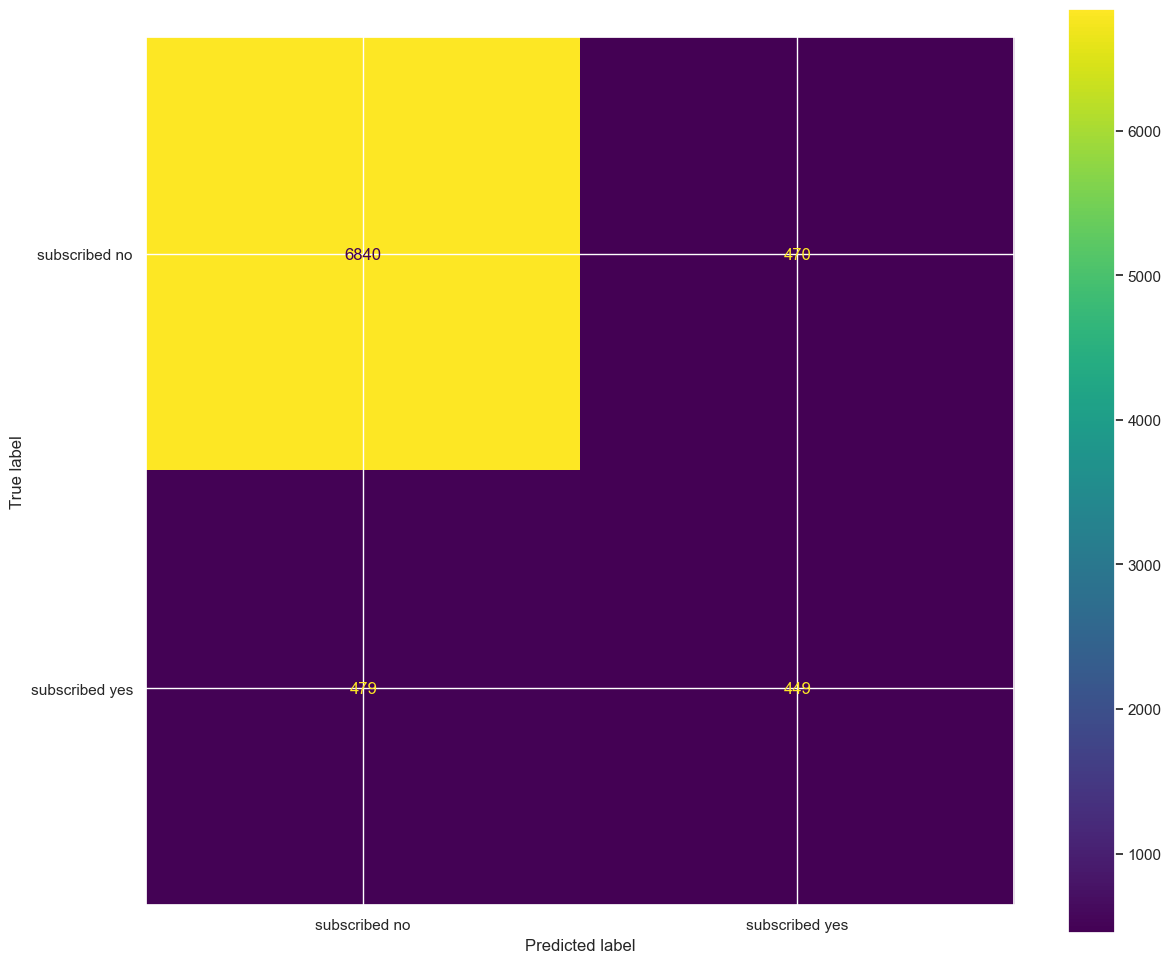

In [40]:
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]
threshold = 0.3
xgb_pred_final = (xgb_probs >= threshold).astype(int)
xgb_confusion = confusion_matrix(y_test, xgb_pred_final)  # Now using the imported function
disp = ConfusionMatrixDisplay(confusion_matrix=xgb_confusion, display_labels=labels)
disp.plot()

print(f"=== Final Report Classification (Threshold {threshold}) ===")
print(classification_report(y_test, xgb_pred_final, target_names=['subscribed_no', 'subscribed_yes']))


=== Final Report Classification ===
                precision    recall  f1-score   support

 subscribed_no       0.93      0.94      0.94      7310
subscribed_yes       0.49      0.48      0.49       928

      accuracy                           0.88      8238
     macro avg       0.71      0.71      0.71      8238
  weighted avg       0.88      0.88      0.88      8238



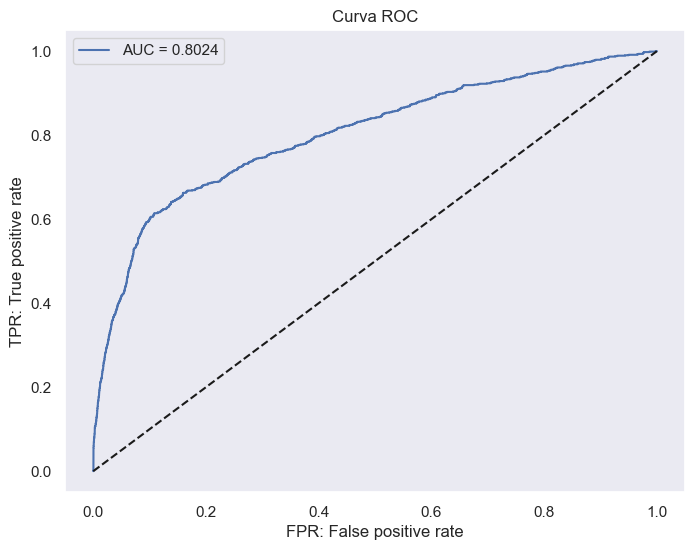

AUC Final no Teste: 0.8024


In [41]:
y_test_str = y_test.apply(subscribed_yes_no)

report = classification_report(y_test, xgb_pred_final, target_names=['subscribed_no', 'subscribed_yes'])
print("=== Final Report Classification ===")
print(report)

xgb_auc = roc_auc_score(y_test, xgb_probs)

fpr_all, tpr_all, th_all = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr_all, tpr_all, label=f'AUC = {xgb_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR: False positive rate')
plt.ylabel('TPR: True positive rate')
plt.title('Curva ROC')
plt.legend()
plt.grid()
plt.show()

print(f'AUC Final no Teste: {xgb_auc:.4f}')


In [42]:
# RESULTS FOE EACH THRESHOLD XGB
y_probs = best_xgb.predict_proba(X_test)[:, 1]

for t in [ 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    preds = (y_probs > t).astype(int)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    print(f"Threshold {t}: Precision={prec:.2f}, Recall={rec:.2f}")

Threshold 0.2: Precision=0.45, Recall=0.58
Threshold 0.3: Precision=0.49, Recall=0.48
Threshold 0.4: Precision=0.58, Recall=0.35
Threshold 0.5: Precision=0.64, Recall=0.25
Threshold 0.6: Precision=0.72, Recall=0.16
Threshold 0.7: Precision=0.75, Recall=0.12
Threshold 0.8: Precision=0.94, Recall=0.05


### 4.3 CROSS-VALIDATION

In [43]:
# CREATE pipeline for SMOTE, and then train XGB
pipeline = imbpipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('model', best_xgb)
])

#cross-validation
cv_scores = cross_val_score(pipeline, X_train, y_train, 
                            cv=5, scoring='roc_auc', n_jobs=2)

# results
print('=======CROSS-VALIDATION RESULTS:======')
print(f"AUC scores per fold: {cv_scores}")
print(f"Average AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Standart Deviation: {cv_scores.std():.4f}")
print("=" * 30)

=======CROSS-VALIDATION RESULTS:======
AUC scores per fold: [0.77810677 0.78725716 0.79379243 0.77963009 0.79230087]
Average AUC: 0.7862 (+/- 0.0064)
Standart Deviation: 0.0064


### 4.4 Final result

Final result Threshold 0.3:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      7310
           1       0.47      0.49      0.48       928

    accuracy                           0.88      8238
   macro avg       0.70      0.71      0.71      8238
weighted avg       0.88      0.88      0.88      8238

AUC Final Test: 0.8024


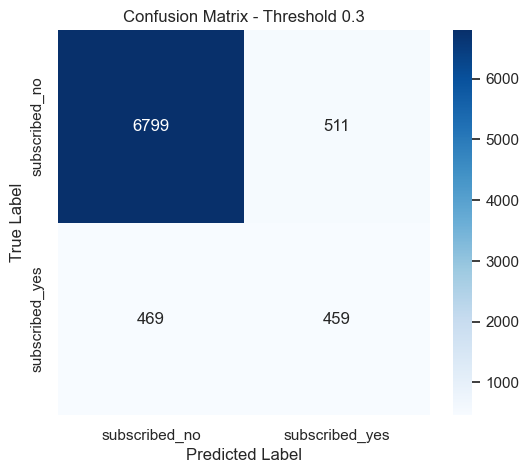

In [44]:
print(f"Final result Threshold {novo_threshold}:")
print(classification_report(y_test, y_pred_final))
print(f'AUC Final Test: {xgb_auc:.4f}')

# confusion matrix to see the real impact
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_final), cmap='Blues', xticklabels=['subscribed_no', 'subscribed_yes'], yticklabels=['subscribed_no', 'subscribed_yes'],annot=True, fmt='d')
plt.title(f'Confusion Matrix - Threshold {novo_threshold}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


The confusion matrix for the XGBoost model at a 0.3 threshold demonstrates a highly effective balance for a banking campaign, showing that by filtering out 6,799 disinterested customers, the model significantly optimizes operational efficiency. With 459 True Positives, the model captures nearly half of the total subscription potential, while the 511 False Positives indicate a healthy precision rate of approximately 47%, meaning nearly one in every two calls results in a successful deposit—a major improvement over random targeting. Although 469 False Negatives represent missed opportunities, this specific threshold configuration acts as a strategic "sweet spot" that minimizes call center fatigue while maintaining a steady volume of new subscriptions, providing the bank with a reliable and scalable tool for targeted marketing.

### 4.5 FEATURE IMPORTANCES XGBOOST

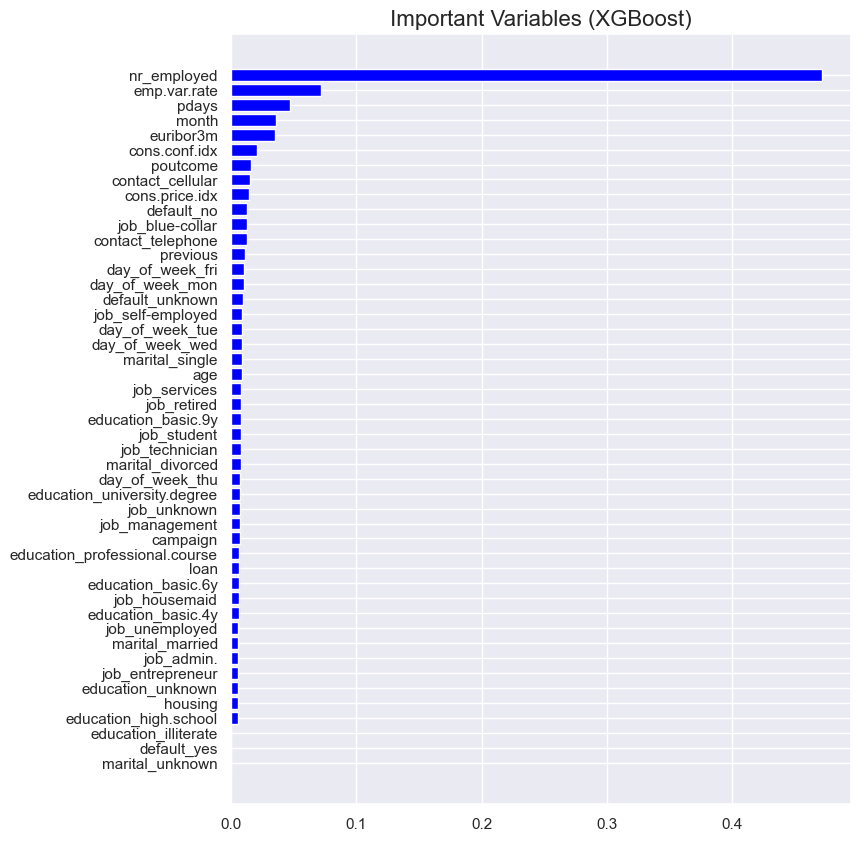

In [45]:
feature_importances = pd.DataFrame(
    best_xgb.feature_importances_,
    index = X_train.columns,
    columns=['importance']
).sort_values('importance', ascending=True)

plt.figure(figsize=(8,10))
plt.title('Important Variables (XGBoost)', fontsize=16)
plt.barh(feature_importances.index, feature_importances['importance'], color='blue')
plt.show()

This graphs shows that the clients are more dependant of social and economic context attributes, than from personal contexts to accept the banks subscriptions.